# SBM vs PCA on Hippocampal Connectivity

Companion to `sbm_pca_comparison.py`. Runs PCA and SBM on six adjacency-matrix
variants (3 direction-types × 2 region-sets) and produces **12 plots** so the
number of meaningful PCs can be compared to the SBM-inferred block count `B`.

**Direction-types**

- `afferent` — only partner → HPC edges retained.
- `efferent` — only HPC → partner edges retained.
- `both` — bidirectional (HPC ↔ partner) edges retained.

**Region-sets** (`individual` is variant-specific)

- `shared` — the 72 partners with **both** afferent and efferent HPC connections.
- `individual`:
  - afferent → all ~96 partners that project to HPC.
  - efferent → all ~165 partners HPC projects to.
  - both → the union ~189, every region with **any** HPC connection.

**All variants zero out:**
- non-HPC ↔ non-HPC edges (partner ↔ partner block)
- HPC ↔ HPC edges (per the new spec — differs from `hippocampal_sbm.ipynb`)
- plus the direction-specific zeroing.

An **ADDENDUM** at the bottom reruns the three direction-types using a single
union (~189) node set across all three, so they're node-comparable.

> Runtime note: a full run is roughly 10–15 minutes (9 SBM fits with 1500 MCMC
> samples each). For faster iteration, lower `N_COLLECT` in the setup cell.

## Setup

In [1]:
%matplotlib inline
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import graph_tool.all as gt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from helpers import log_weight_transform

# Constants
HIPPOCAMPAL_REGIONS = ['DG', 'CA3', 'CA2', 'CA1v', 'CA1d', 'SUBv', 'SUBd']
PCA_THRESHOLD = 0.90          # cumulative variance threshold for "n_pcs"
N_COLLECT     = 1500          # MCMC samples after burn-in
BURN_WAIT     = 1000
SEED          = 42

# Paths (assumes the notebook runs from the scripts/ directory).
DATA_PATH = Path('../data/average_connectome_data.csv')
OUT_DIR   = Path('../output/sbm_pca_comparison')
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('Output dir:', OUT_DIR.resolve())

Output dir: /Users/cweinber/Documents/fyp/br2f_connectome/output/sbm_pca_comparison


## Helper functions

These mirror the functions in `sbm_pca_comparison.py`. The two plotting helpers
differ slightly — they **do not** call `plt.close()`, so each figure displays
inline in the calling cell while still being saved to disk.

You only need to run this cell once; every scenario cell below is a one-liner
calling `run_scenario`.

In [2]:
def load_connectome():
    # Load the ordinal 0-7 connectome. Index = source, columns = target.
    df = pd.read_csv(DATA_PATH, header=0, index_col=0)
    return df.fillna(0.0)


def get_partner_sets(df_connectome, hpc_regions):
    # Return the four partner sets used in the analysis.
    non_hpc = [r for r in df_connectome.index if r not in hpc_regions]

    # FROM HPC: rows = HPC, columns = non-HPC regions HPC projects to.
    hpc_rows = df_connectome.loc[hpc_regions, non_hpc]
    efferent_targets = hpc_rows.columns[(hpc_rows.values > 0).any(axis=0)].tolist()

    # TO HPC: rows = non-HPC, columns = HPC. Sources are rows with any nonzero col.
    hpc_cols = df_connectome.loc[non_hpc, hpc_regions]
    afferent_sources = hpc_cols.index[(hpc_cols.values > 0).any(axis=1)].tolist()

    shared = sorted(set(afferent_sources) & set(efferent_targets),
                    key=efferent_targets.index)
    union  = sorted(set(afferent_sources) | set(efferent_targets),
                    key=lambda r: (r not in efferent_targets, r))

    return {
        'efferent_targets': efferent_targets,
        'afferent_sources': afferent_sources,
        'shared':           shared,
        'union':            union,
    }


def build_adjacency(df_connectome, hpc_regions, partner_regions, direction):
    # Square directed adjacency matrix for one scenario, with all zeroings applied.
    region_order = list(partner_regions) + list(hpc_regions)
    A = df_connectome.loc[region_order, region_order].copy()

    # Always: zero non-HPC <-> non-HPC and HPC <-> HPC.
    A.loc[partner_regions, partner_regions] = 0.0
    A.loc[hpc_regions,     hpc_regions]     = 0.0

    if direction == 'afferent':
        A.loc[hpc_regions, partner_regions] = 0.0       # keep partner -> HPC only
    elif direction == 'efferent':
        A.loc[partner_regions, hpc_regions] = 0.0       # keep HPC -> partner only
    elif direction == 'both':
        pass
    else:
        raise ValueError(f'unknown direction: {direction!r}')
    return A


def feature_vectors_for_pca(df_connectome, hpc_regions, partner_regions, direction):
    # Matrix for PCA: rows = M partner regions (SAMPLES), cols = HPC subregions (FEATURES).
    # sklearn convention is (n_samples, n_features), so this is (M, 7) -- or (M, 14)
    # for 'both' (concatenating incoming + outgoing HPC features).
    # PCA on this matrix asks: how many HPC-profile dimensions do the M partners need?
    df_aff = df_connectome.loc[partner_regions, hpc_regions]         # partner rows; partner -> HPC
    df_eff = df_connectome.loc[hpc_regions, partner_regions].T       # partner rows; HPC -> partner

    if direction == 'afferent':
        return df_aff
    elif direction == 'efferent':
        return df_eff
    elif direction == 'both':
        df_aff = df_aff.add_prefix('in_')
        df_eff = df_eff.add_prefix('out_')
        return pd.concat([df_aff, df_eff], axis=1)
    else:
        raise ValueError(f'unknown direction: {direction!r}')


def fit_sbm_directed(adjacency_log, n_collect=N_COLLECT, burn_wait=BURN_WAIT, seed=SEED):
    # Directed weighted DC-SBM with MDL + MCMC consensus.
    # `adjacency_log` is assumed already log-transformed; entries in [0, 1].
    gt.seed_rng(seed); np.random.seed(seed)

    region_names = list(adjacency_log.index)
    W = adjacency_log.values
    n = len(region_names)

    # Build directed weighted graph; only non-zero entries become edges.
    g = gt.Graph(directed=True)
    name_vp = g.new_vp('string'); weight_ep = g.new_ep('double')
    vs = [g.add_vertex() for _ in range(n)]
    for i, v in enumerate(vs):
        name_vp[v] = region_names[i]
    for i in range(n):
        for j in range(n):
            w = W[i, j]
            if w > 0:
                e = g.add_edge(vs[i], vs[j]); weight_ep[e] = w
    g.vp['name'] = name_vp; g.ep['weight'] = weight_ep

    # MDL fit + MCMC consensus.
    state = gt.minimize_blockmodel_dl(
        g, state_args=dict(recs=[weight_ep], rec_types=['real-exponential']))
    gt.mcmc_equilibrate(state, wait=burn_wait, mcmc_args=dict(niter=10))
    partitions = []
    gt.mcmc_equilibrate(state, force_niter=n_collect, mcmc_args=dict(niter=10),
                        callback=lambda s: partitions.append(s.b.a.copy()))
    pmode = gt.PartitionModeState(partitions, converge=True)
    b_consensus = pmode.get_max(g)

    blocks = np.array([int(b_consensus[v]) for v in g.vertices()])
    block_ids = sorted(set(blocks))
    B = len(block_ids)

    # Block-pair affinity (all-cells mean) for visualization.
    binv = np.array([block_ids.index(b) for b in blocks])
    omega = np.zeros((B, B)); counts = np.zeros((B, B))
    for r in range(B):
        rmask = binv == r
        for s in range(B):
            cell = W[np.ix_(rmask, binv == s)]
            omega[r, s] = cell.sum(); counts[r, s] = cell.size
    omega = np.divide(omega, counts, out=np.zeros_like(omega), where=counts > 0)

    return {
        'B': B, 'blocks': blocks, 'block_ids': block_ids, 'binv': binv,
        'node_names': region_names, 'omega': omega, 'adj_log': W, 'graph': g,
    }


def plot_sbm(result, scenario_label, save_path=None):
    # Two-panel SBM figure (sorted adjacency + omega heatmap). Displays inline.
    W = result['adj_log']; binv = result['binv']; omega = result['omega']
    B = result['B']; block_ids = result['block_ids']

    order = np.argsort(binv, kind='stable')
    W_ord = W[np.ix_(order, order)]; binv_ord = binv[order]
    boundaries = np.where(np.diff(binv_ord) != 0)[0] + 1

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    vmax = float(W.max()) if W.max() > 0 else 1.0
    axes[0].imshow(W_ord, cmap='viridis', vmin=0, vmax=vmax, aspect='equal')
    axes[0].set_title('Adjacency (log-weighted, sorted by block)')
    axes[0].set_xlabel('TO node (sorted by block)')
    axes[0].set_ylabel('FROM node (sorted by block)')
    for b in boundaries:
        axes[0].axhline(b - 0.5, color='red', lw=0.5)
        axes[0].axvline(b - 0.5, color='red', lw=0.5)

    sns.heatmap(omega, annot=True, fmt='.3f', cmap='viridis', ax=axes[1],
                xticklabels=[f'b{b}' for b in block_ids],
                yticklabels=[f'b{b}' for b in block_ids],
                cbar_kws={'fraction': 0.04, 'pad': 0.02})
    axes[1].set_title(rf'$\omega[r \to s]$  (B = {B} blocks)')
    axes[1].set_xlabel('TO block'); axes[1].set_ylabel('FROM block')

    fig.suptitle(f'SBM: {scenario_label}', fontsize=14, y=1.02)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=120, bbox_inches='tight')
    return fig



def l2_normalize_rows(feat):
    # Divide each sample (row) by its L2 norm so every sample vector has unit length.
    # PCA then keys on the *shape* of each partner's HPC connectivity profile rather
    # than its overall connection magnitude. (Replaces the earlier column-standardize
    # step.) All-zero rows are left as zeros to avoid divide-by-zero.
    X = feat.values.astype(float)
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return pd.DataFrame(X / norms, index=feat.index, columns=feat.columns)


def fit_pca(feature_matrix, threshold=PCA_THRESHOLD):
    # Fit PCA on (n_obs x n_features). Returns variance ratios + n_pcs at threshold.
    X = np.asarray(feature_matrix.values, dtype=float)
    max_pcs = min(X.shape)
    pca = PCA(n_components=max_pcs, svd_solver='full')
    pca.fit(X)
    cumulative = np.cumsum(pca.explained_variance_ratio_)
    n_pcs_at_threshold = int(np.searchsorted(cumulative, threshold) + 1)
    return {
        'explained_variance_ratio': pca.explained_variance_ratio_,
        'cumulative':               cumulative,
        'n_pcs_at_threshold':       n_pcs_at_threshold,
        'pca':                      pca,
    }


def plot_pca(result, scenario_label, save_path=None, threshold=PCA_THRESHOLD):
    # Per-component bar + cumulative line with the threshold marked. Displays inline.
    var = result['explained_variance_ratio'] * 100
    cum = result['cumulative'] * 100
    n   = result['n_pcs_at_threshold']
    components = np.arange(1, len(var) + 1)

    fig, ax = plt.subplots(figsize=(8.5, 5))
    ax.bar(components, var, color='royalblue', edgecolor='k', alpha=0.75,
           label='per-component variance')
    ax.set_xlabel('Principal component')
    ax.set_ylabel('Per-component variance (%)', color='royalblue')
    ax.tick_params(axis='y', labelcolor='royalblue')
    ax.set_xticks(components)

    ax2 = ax.twinx()
    ax2.plot(components, cum, 'ro-', label='cumulative variance')
    ax2.axhline(threshold * 100, color='gray', linestyle='--',
                label=f'{int(threshold*100)}% threshold')
    ax2.axvline(n, color='red', linestyle=':', label=f'{n} PCs reach threshold')
    ax2.set_ylabel('Cumulative variance (%)', color='red')
    ax2.tick_params(axis='y', labelcolor='red'); ax2.set_ylim(0, 105)

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc='center right', framealpha=0.9)

    ax.set_title(f'PCA: {scenario_label}')
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=120, bbox_inches='tight')
    return fig


def run_scenario(df_connectome, partner_regions, direction, region_set_label, out_dir):
    # Run one (direction, region-set) scenario end-to-end and return a summary row.
    label = f'{direction} / {region_set_label}'
    print(f'Scenario: {label}  ({len(partner_regions)} partners)')

    # 1. Square directed adjacency with all zeroings, then log-transform.
    A_raw = build_adjacency(df_connectome, HIPPOCAMPAL_REGIONS, partner_regions, direction)
    A_log = pd.DataFrame(log_weight_transform(A_raw.values),
                         index=A_raw.index, columns=A_raw.columns)

    # 2. SBM.
    sbm_res = fit_sbm_directed(A_log)
    print(f'  SBM inferred B = {sbm_res["B"]} blocks')
    sbm_path = out_dir / f'sbm__{direction}__{region_set_label}.png'
    plot_sbm(sbm_res, label, sbm_path)

    # 3. PCA on 7 x M feature vectors.
    feat = feature_vectors_for_pca(df_connectome, HIPPOCAMPAL_REGIONS,
                                   partner_regions, direction)
    feat_log = pd.DataFrame(log_weight_transform(feat.values),
                            index=feat.index, columns=feat.columns)
    feat_norm = l2_normalize_rows(feat_log)   # unit-length each sample; no column standardization
    pca_res = fit_pca(feat_norm)
    print(f'  PCA: {pca_res["n_pcs_at_threshold"]} PCs reach '
          f'{int(PCA_THRESHOLD*100)}% (max possible: {min(feat_norm.shape)})')
    pca_path = out_dir / f'pca__{direction}__{region_set_label}.png'
    plot_pca(pca_res, label, pca_path)

    return {
        'direction':   direction,
        'region_set':  region_set_label,
        'n_partners':  len(partner_regions),
        'n_nodes':     A_raw.shape[0],
        'B':           sbm_res['B'],
        'n_pcs':       pca_res['n_pcs_at_threshold'],
    }

## Load data and compute the partner sets

In [3]:
df_connectome = load_connectome()
print('Connectome shape:', df_connectome.shape)

partner_sets = get_partner_sets(df_connectome, HIPPOCAMPAL_REGIONS)
print('Partner-set sizes:')
for k, v in partner_sets.items():
    print(f'  {k:>18s}: {len(v)}')

main_results = []

Connectome shape: (392, 392)
Partner-set sizes:
    efferent_targets: 165
    afferent_sources: 96
              shared: 72
               union: 189


---
## Main analysis: 6 variant-specific scenarios

Three direction-types × two region-set choices. `individual` is variant-specific:
- **afferent / individual** uses all ~96 partners that project to HPC.
- **efferent / individual** uses all ~165 partners HPC projects to.
- **both / individual** uses the union ~189.

Each scenario cell produces two plots (SBM block model + PCA scree) and appends
a row to `main_results`.

### 1. Afferent / shared

In [4]:
main_results.append(run_scenario(
    df_connectome, partner_sets['shared'], 'afferent', 'shared', OUT_DIR))

Scenario: afferent / shared  (72 partners)
  SBM inferred B = 5 blocks
  PCA: 5 PCs reach 90% (max possible: 7)


### 2. Afferent / individual (~96 afferent sources)

In [5]:
main_results.append(run_scenario(
    df_connectome, partner_sets['afferent_sources'], 'afferent', 'individual', OUT_DIR))

Scenario: afferent / individual  (96 partners)
  SBM inferred B = 5 blocks
  PCA: 5 PCs reach 90% (max possible: 7)


### 3. Efferent / shared

In [6]:
main_results.append(run_scenario(
    df_connectome, partner_sets['shared'], 'efferent', 'shared', OUT_DIR))

Scenario: efferent / shared  (72 partners)
  SBM inferred B = 5 blocks
  PCA: 3 PCs reach 90% (max possible: 7)


### 4. Efferent / individual (~165 efferent targets)

In [7]:
main_results.append(run_scenario(
    df_connectome, partner_sets['efferent_targets'], 'efferent', 'individual', OUT_DIR))

Scenario: efferent / individual  (165 partners)
  SBM inferred B = 6 blocks
  PCA: 3 PCs reach 90% (max possible: 7)


### 5. Both / shared

In [8]:
main_results.append(run_scenario(
    df_connectome, partner_sets['shared'], 'both', 'shared', OUT_DIR))

Scenario: both / shared  (72 partners)
  SBM inferred B = 8 blocks
  PCA: 7 PCs reach 90% (max possible: 14)


### 6. Both / individual (~189 union)

In [9]:
main_results.append(run_scenario(
    df_connectome, partner_sets['union'], 'both', 'individual', OUT_DIR))

Scenario: both / individual  (189 partners)
  SBM inferred B = 12 blocks
  PCA: 7 PCs reach 90% (max possible: 14)


### Main summary table

In [10]:
summary_main = pd.DataFrame(main_results)
summary_main.to_csv(OUT_DIR / 'summary_main.csv', index=False)
summary_main

,direction,region_set,n_partners,n_nodes,B,n_pcs
0,afferent,shared,72,79,5,5
1,afferent,individual,96,103,5,5
2,efferent,shared,72,79,5,3
3,efferent,individual,165,172,6,3
4,both,shared,72,79,8,7
5,both,individual,189,196,12,7


---
---
# ============================================================
#   ADDENDUM
# ============================================================

The three direction-types below all use **one single node set**: the union ~189
of every region with any HPC connection. This makes the three SBM partitions
directly node-comparable.

This addendum is **not part of the main 12-plot analysis above** — it's an extra
sensitivity check on the choice of node set.

### Addendum: afferent / union ~189

In [11]:
addendum_results = []
addendum_results.append(run_scenario(
    df_connectome, partner_sets['union'], 'afferent', 'union_addendum', OUT_DIR))

Scenario: afferent / union_addendum  (189 partners)
  SBM inferred B = 5 blocks
  PCA: 5 PCs reach 90% (max possible: 7)


### Addendum: efferent / union ~189

In [12]:
addendum_results.append(run_scenario(
    df_connectome, partner_sets['union'], 'efferent', 'union_addendum', OUT_DIR))

Scenario: efferent / union_addendum  (189 partners)
  SBM inferred B = 6 blocks
  PCA: 3 PCs reach 90% (max possible: 7)


### Addendum: both / union ~189

In [13]:
addendum_results.append(run_scenario(
    df_connectome, partner_sets['union'], 'both', 'union_addendum', OUT_DIR))

Scenario: both / union_addendum  (189 partners)
  SBM inferred B = 12 blocks
  PCA: 7 PCs reach 90% (max possible: 14)


### Addendum summary table

In [14]:
summary_addendum = pd.DataFrame(addendum_results)
summary_addendum.to_csv(OUT_DIR / 'summary_addendum.csv', index=False)
summary_addendum

,direction,region_set,n_partners,n_nodes,B,n_pcs
0,afferent,union_addendum,189,196,5,5
1,efferent,union_addendum,189,196,6,3
2,both,union_addendum,189,196,12,7


---
---
# ============================================================
#   Decomposed visualisations per numbered scenario
# ============================================================

The plots above (SBM block-sorted adjacency + ω heatmap; PCA bar+cumulative)
are one view of each scenario. This section adds a second, sharper view:

- **SBM** — the **decomposed** `B × B` colormap from `hippocampal_sbm.ipynb`: three
  panels for density `ρ`, edge-mean `μ̂`, and the affinity `ω = ρ · μ̂` so you
  can tell whether structure is driven by *how often* blocks connect, *how
  strongly* they connect, or both.
- **PCA** — a single **cumulative variance** curve with the threshold and the
  number of PCs needed marked. Cleaner than the bar+twinx view above when
  you only care about "how many PCs reach 90%".

To avoid re-fitting SBM and PCA again, each cell caches its results in a
module-level `scenario_cache` dict (keyed by `(direction, region_set_label)`).
The **first** time you run a scenario cell it fits + caches; subsequent runs
just replot from the cache. If you've already run the main + addendum sections
above and want to share state with them, you can modify `run_scenario` in the
helpers cell to write into `scenario_cache` — by default this viz section
re-fits, so it's fully self-contained.

In [15]:
# Cache so each (direction, region_set) is fit at most once across re-runs.
scenario_cache = scenario_cache if 'scenario_cache' in dir() else {}


def decompose_omega(W, binv, B):
    # Split the all-cells block-pair mean omega[r,s] into:
    #   rho[r,s]      = fraction of cells in (r,s) with a non-zero edge   (density)
    #   mu_hat[r,s]   = mean log-weight over EXISTING edges only          (edge-mean)
    # By construction, rho * mu_hat == omega (the all-cells mean).
    rho = np.zeros((B, B))
    mu  = np.zeros((B, B))
    for r in range(B):
        rmask = binv == r
        for s in range(B):
            cell = W[np.ix_(rmask, binv == s)]
            edges = cell > 0
            rho[r, s] = edges.mean()
            mu[r, s]  = cell[edges].mean() if edges.any() else 0.0
    return rho, mu


def plot_sbm_decomposed(sbm_res, scenario_label, save_path=None):
    # Three-panel B x B heatmap: density (rho), edge-mean (mu_hat), affinity (omega).
    W         = sbm_res['adj_log']
    binv      = sbm_res['binv']
    omega     = sbm_res['omega']
    B         = sbm_res['B']
    block_ids = sbm_res['block_ids']

    rho, mu = decompose_omega(W, binv, B)
    labels  = [f'b{b}' for b in block_ids]

    panels = [
        (rho,   r'Density  $\rho_{rs}$' '\n' r'(fraction of pairs that connect)',     'Blues'),
        (mu,    r'Edge-mean  $\hat{\mu}_{rs}$' '\n' r'(mean log-weight | edge exists)', 'Reds'),
        (omega, r'Affinity  $\omega_{rs} = \rho_{rs}\,\hat{\mu}_{rs}$' '\n' r'(all-cells mean)', 'viridis'),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    for ax, (M, title, cmap) in zip(axes, panels):
        sns.heatmap(M, annot=True, fmt='.3f', cmap=cmap,
                    xticklabels=labels, yticklabels=labels, ax=ax,
                    cbar_kws={'fraction': 0.04, 'pad': 0.02})
        ax.set_title(title); ax.set_xlabel('TO block (s)'); ax.set_ylabel('FROM block (r)')

    fig.suptitle(f'SBM decomposition — {scenario_label}   (B = {B} blocks)',
                 fontsize=14, y=1.04)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=120, bbox_inches='tight')
    return fig


def plot_pca_cumulative(pca_res, scenario_label, save_path=None, threshold=PCA_THRESHOLD):
    # Single cumulative-variance line plot. Threshold + crossing PC marked.
    cum = pca_res['cumulative'] * 100
    n   = pca_res['n_pcs_at_threshold']
    components = np.arange(1, len(cum) + 1)

    fig, ax = plt.subplots(figsize=(8.5, 5))
    ax.plot(components, cum, 'ro-', lw=2, markersize=7)
    ax.axhline(threshold * 100, color='gray', linestyle='--',
               label=f'{int(threshold * 100)}% threshold')
    ax.axvline(n, color='red', linestyle=':', alpha=0.6,
               label=f'{n} PCs reach threshold')

    # Annotate the crossing point.
    ax.annotate(f'{cum[n - 1]:.1f}%', xy=(n, cum[n - 1]),
                xytext=(n + 0.2, cum[n - 1] - 6), fontsize=10, color='red')

    ax.set_xlabel('Principal component')
    ax.set_ylabel('Cumulative variance explained (%)')
    ax.set_xticks(components)
    ax.set_ylim(0, 105)
    ax.set_title(f'PCA cumulative variance — {scenario_label}')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=120, bbox_inches='tight')
    return fig


def get_or_fit(direction, region_set_label, partner_regions):
    # Look up cached SBM + PCA results; fit only if not cached.
    key = (direction, region_set_label)
    if key in scenario_cache:
        print(f'cache hit: {key}')
        return scenario_cache[key]

    print(f'fitting {key} ...')
    A_raw = build_adjacency(df_connectome, HIPPOCAMPAL_REGIONS, partner_regions, direction)
    A_log = pd.DataFrame(log_weight_transform(A_raw.values),
                         index=A_raw.index, columns=A_raw.columns)
    sbm_res = fit_sbm_directed(A_log)

    feat = feature_vectors_for_pca(df_connectome, HIPPOCAMPAL_REGIONS,
                                   partner_regions, direction)
    feat_log = pd.DataFrame(log_weight_transform(feat.values),
                            index=feat.index, columns=feat.columns)
    feat_norm = l2_normalize_rows(feat_log)   # unit-length each sample; no column standardization
    pca_res = fit_pca(feat_norm)

    scenario_cache[key] = {'sbm': sbm_res, 'pca': pca_res,
                           'partners': partner_regions, 'label': f'{direction} / {region_set_label}'}
    print(f'  B = {sbm_res["B"]}   n_pcs(90%) = {pca_res["n_pcs_at_threshold"]}')
    return scenario_cache[key]

### 1. Afferent / shared

Shared 72 partners; only partner → HPC retained.

fitting ('afferent', 'shared') ...
  B = 5   n_pcs(90%) = 5


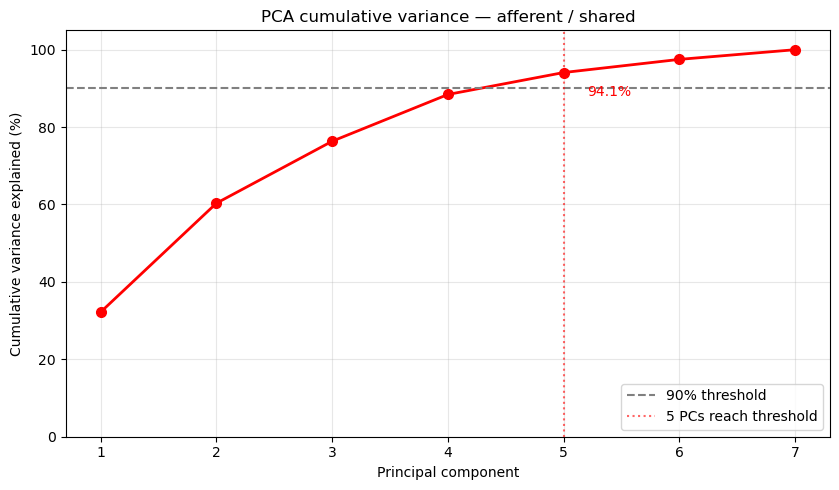

In [16]:
res = get_or_fit('afferent', 'shared', partner_sets['shared'])
plot_sbm_decomposed(res['sbm'], res['label'],
                    OUT_DIR / 'sbm_decomposed__afferent__shared.png')
plot_pca_cumulative(res['pca'], res['label'],
                    OUT_DIR / 'pca_cumulative__afferent__shared.png')

### 2. Afferent / individual

~96 afferent sources; only partner → HPC retained.

fitting ('afferent', 'individual') ...
  B = 5   n_pcs(90%) = 5


/var/folders/4k/31jdbs595pn4tslnsm4nxmzm0000gq/T/ipykernel_2905/1694908896.py:38: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))


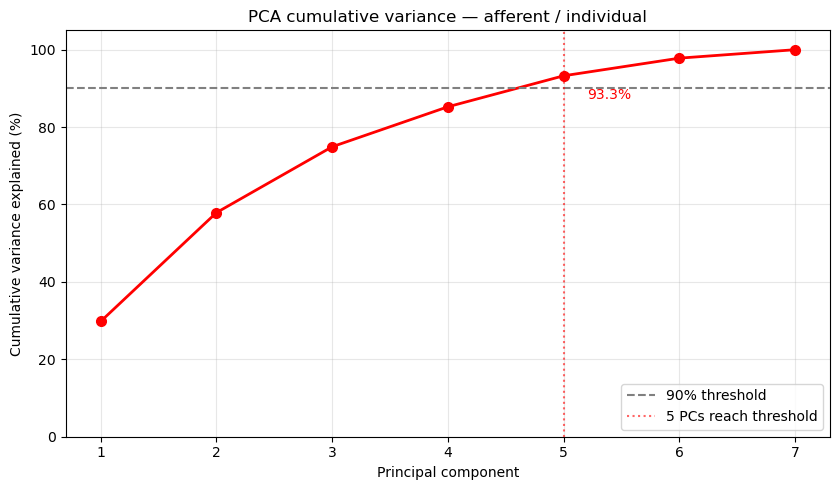

In [17]:
res = get_or_fit('afferent', 'individual', partner_sets['afferent_sources'])
plot_sbm_decomposed(res['sbm'], res['label'],
                    OUT_DIR / 'sbm_decomposed__afferent__individual.png')
plot_pca_cumulative(res['pca'], res['label'],
                    OUT_DIR / 'pca_cumulative__afferent__individual.png')

### 3. Efferent / shared

Shared 72 partners; only HPC → partner retained.

fitting ('efferent', 'shared') ...
  B = 5   n_pcs(90%) = 3


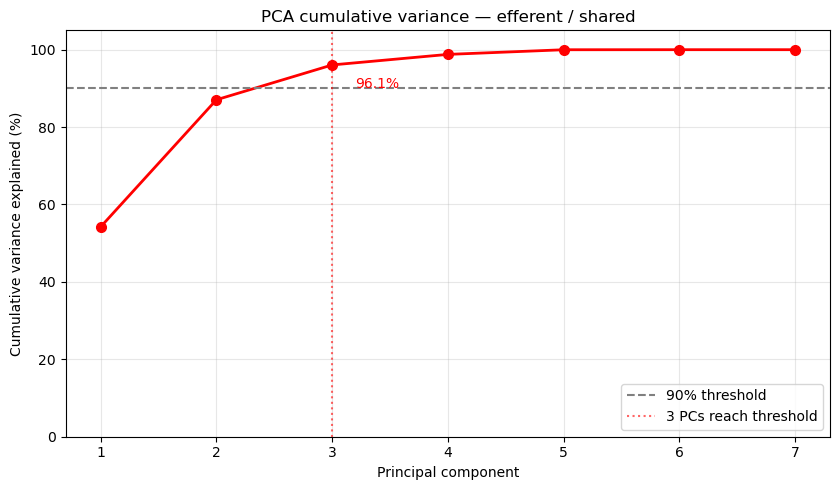

In [18]:
res = get_or_fit('efferent', 'shared', partner_sets['shared'])
plot_sbm_decomposed(res['sbm'], res['label'],
                    OUT_DIR / 'sbm_decomposed__efferent__shared.png')
plot_pca_cumulative(res['pca'], res['label'],
                    OUT_DIR / 'pca_cumulative__efferent__shared.png')

### 4. Efferent / individual

~165 efferent targets; only HPC → partner retained.

fitting ('efferent', 'individual') ...
  B = 6   n_pcs(90%) = 3


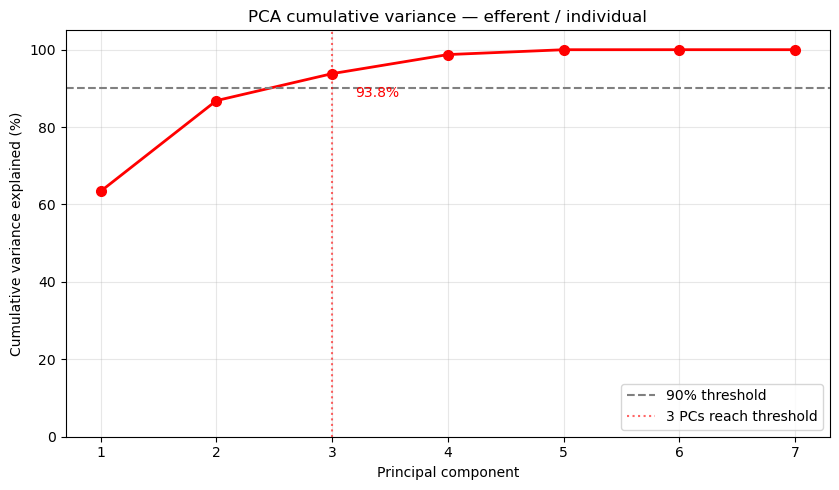

In [19]:
res = get_or_fit('efferent', 'individual', partner_sets['efferent_targets'])
plot_sbm_decomposed(res['sbm'], res['label'],
                    OUT_DIR / 'sbm_decomposed__efferent__individual.png')
plot_pca_cumulative(res['pca'], res['label'],
                    OUT_DIR / 'pca_cumulative__efferent__individual.png')

### 5. Both / shared

Shared 72 partners; bidirectional HPC ↔ partner.

fitting ('both', 'shared') ...
  B = 8   n_pcs(90%) = 7


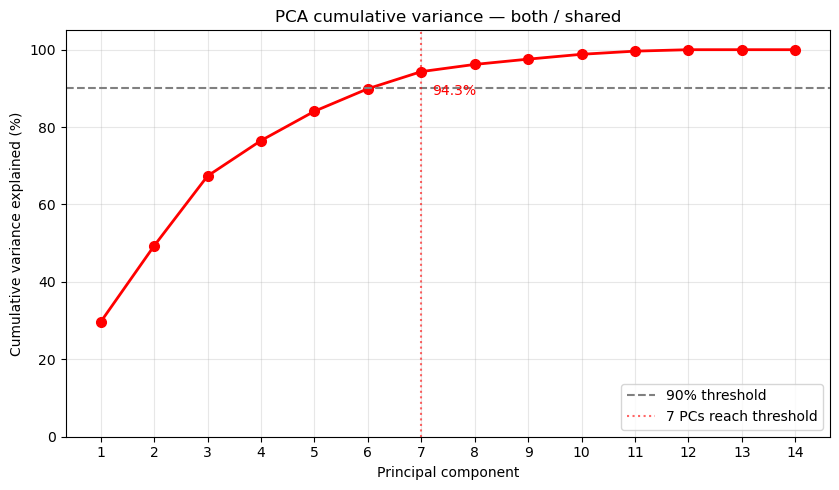

In [20]:
res = get_or_fit('both', 'shared', partner_sets['shared'])
plot_sbm_decomposed(res['sbm'], res['label'],
                    OUT_DIR / 'sbm_decomposed__both__shared.png')
plot_pca_cumulative(res['pca'], res['label'],
                    OUT_DIR / 'pca_cumulative__both__shared.png')

### 6. Both / individual

Union ~189 partners; bidirectional HPC ↔ partner.

fitting ('both', 'individual') ...
  B = 12   n_pcs(90%) = 7


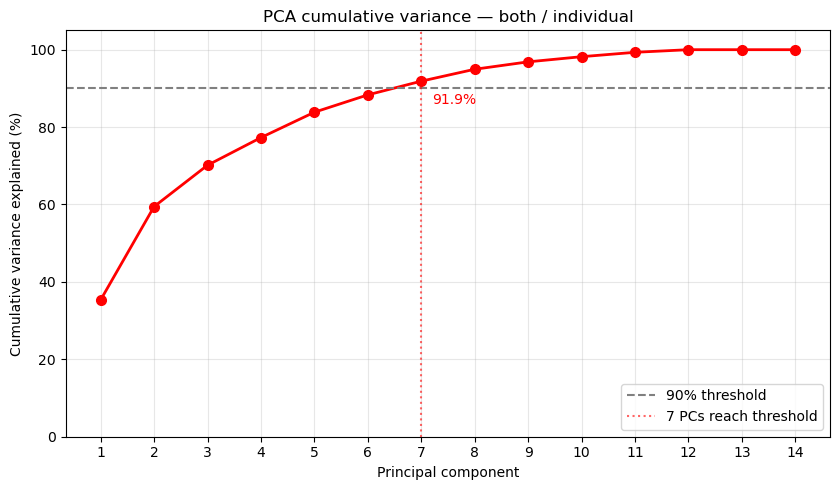

In [21]:
res = get_or_fit('both', 'individual', partner_sets['union'])
plot_sbm_decomposed(res['sbm'], res['label'],
                    OUT_DIR / 'sbm_decomposed__both__individual.png')
plot_pca_cumulative(res['pca'], res['label'],
                    OUT_DIR / 'pca_cumulative__both__individual.png')

### 7. Afferent / union_addendum

Addendum — union ~189 node set; afferent only.

fitting ('afferent', 'union_addendum') ...
  B = 5   n_pcs(90%) = 5


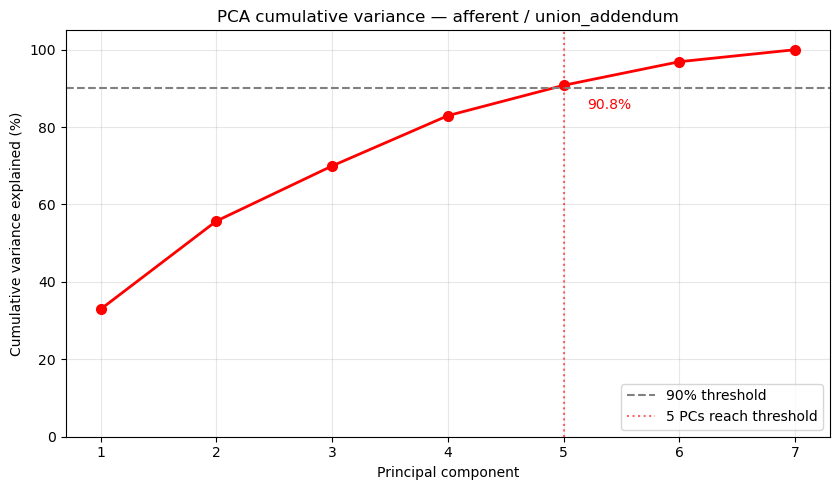

In [22]:
res = get_or_fit('afferent', 'union_addendum', partner_sets['union'])
plot_sbm_decomposed(res['sbm'], res['label'],
                    OUT_DIR / 'sbm_decomposed__afferent__union_addendum.png')
plot_pca_cumulative(res['pca'], res['label'],
                    OUT_DIR / 'pca_cumulative__afferent__union_addendum.png')

### 8. Efferent / union_addendum

Addendum — union ~189 node set; efferent only.

fitting ('efferent', 'union_addendum') ...
  B = 6   n_pcs(90%) = 3


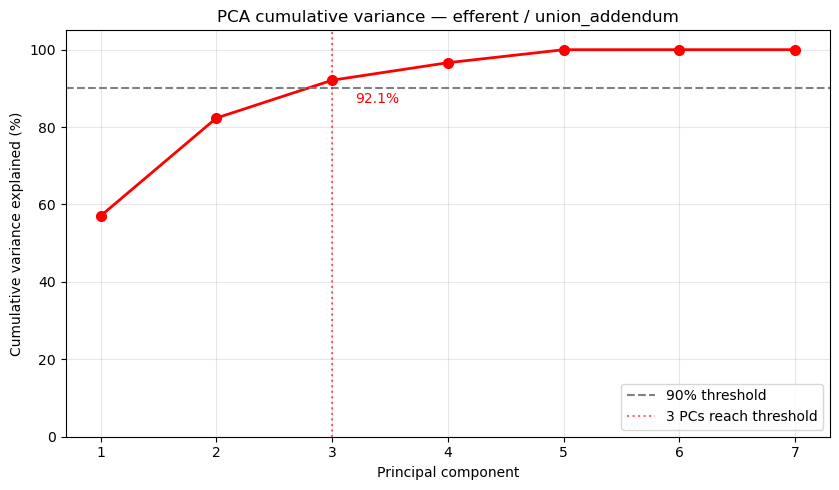

In [23]:
res = get_or_fit('efferent', 'union_addendum', partner_sets['union'])
plot_sbm_decomposed(res['sbm'], res['label'],
                    OUT_DIR / 'sbm_decomposed__efferent__union_addendum.png')
plot_pca_cumulative(res['pca'], res['label'],
                    OUT_DIR / 'pca_cumulative__efferent__union_addendum.png')

### 9. Both / union_addendum

Addendum — union ~189 node set; bidirectional.

fitting ('both', 'union_addendum') ...
  B = 12   n_pcs(90%) = 7


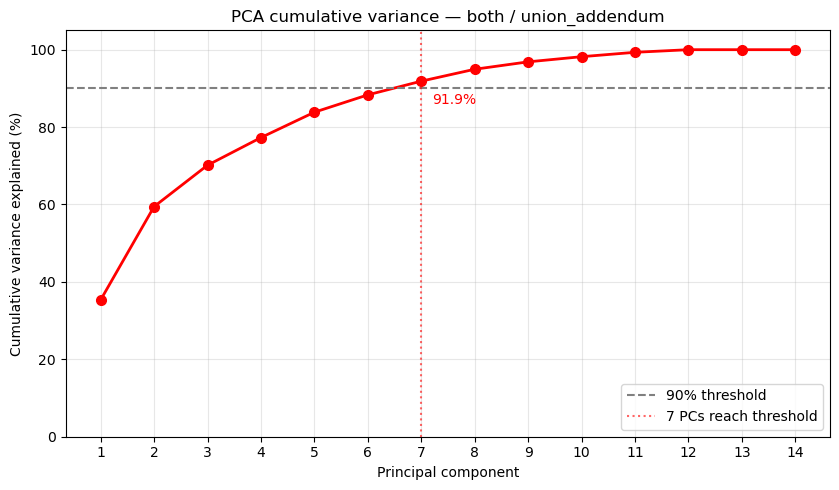

In [24]:
res = get_or_fit('both', 'union_addendum', partner_sets['union'])
plot_sbm_decomposed(res['sbm'], res['label'],
                    OUT_DIR / 'sbm_decomposed__both__union_addendum.png')
plot_pca_cumulative(res['pca'], res['label'],
                    OUT_DIR / 'pca_cumulative__both__union_addendum.png')

---
---
# ============================================================
#   Effective block count $B_\text{eff}$ + HPC block membership
# ============================================================

A direct comparison of **PCA's `n_pcs(90%)`** to **SBM's `B`** is unfair: they
measure different things and live on different scales. PCA's $n_\text{pcs}$ is a
**continuous, variance-aware** measure of "how many dimensions does it take to
capture most of the structure?"  SBM's $B$ is a **discrete, integer count** of
groups — and crucially, $B$ scales with $N$ (more nodes → more groups even if
the underlying structure is the same richness).

To put SBM on the same scale as $n_\text{pcs}$ we use the **effective number of
blocks**, $B_\text{eff}$.

## What is $B_\text{eff}$?

**Mathematically**, given block sizes $n_1, n_2, \ldots, n_B$ with
$N = \sum_r n_r$, define the block-size distribution $p_r = n_r / N$. Then:

$$H \;=\; -\sum_{r=1}^{B} p_r \log p_r
\qquad\qquad
B_\text{eff} \;=\; e^H \;=\; \exp\!\left(-\sum_r p_r \log p_r\right)$$

This is the **exponential of the Shannon entropy** of the block-size
distribution — also known in ecology as the *Hill number of order 1*, in
physics as the *participation ratio*, and in network science generally as
the *effective number of groups*.

## Intuition

$B_\text{eff}$ answers: *"How many equally-sized blocks would give the same
amount of partition diversity as my actual unequal partition?"*

- **If all $B$ blocks have equal size** ($p_r = 1/B$ for all $r$), then
  $H = \log B$ and $B_\text{eff} = B$. The two quantities coincide exactly
  when the partition is perfectly balanced.
- **If one block contains 95% of nodes and the rest are tiny**, $H$ is small
  and $B_\text{eff} \approx 1.1$ — even if $B = 6$. The model technically has
  6 blocks, but functionally it's one giant lump plus a few stragglers.
- **General rule:** $1 \le B_\text{eff} \le B$, with equality on the right
  only when blocks are equally populated.

## Why this is a fairer comparison to PCA's $n_\text{pcs}$

PCA's $n_\text{pcs}(90\%)$ already does an analogous thing — it counts the
number of *meaningful* components (those carrying real variance), not just any
component the model exposes. A partition with `B = 6` where one block has 60
nodes and five blocks have 1 node each is, in a real sense, not "richer" than
a `B = 2` partition of 50/50 — and $B_\text{eff}$ captures that.

## What we'll do with it

The cell after the helpers loops over every scenario in `scenario_cache` and
prints a single comparison table with:

| Column | Meaning |
|---|---|
| `B` | Raw SBM block count (the integer MDL inferred) |
| `B_eff` | Effective block count (continuous; defined above) |
| `n_HPC_blocks` | How many distinct blocks the 7 HPC subregions fall into |
| `HPC_blocks` | The actual HPC-block label(s) |
| `n_pcs(90%)` | PCA's PC count at 90% cumulative variance |

The **`B_eff` vs `n_pcs(90%)`** comparison is the cross-method dimensionality
comparison; the **`n_HPC_blocks`** column directly addresses whether the SBM
captured any send/receive asymmetry *at the HPC subregion level* (where PCA's
3-vs-4 finding lives).

> Requires `scenario_cache` to be populated. Run the numbered viz cells above
> first (or the main/addendum scenarios). If you haven't, this cell will just
> print an empty table.

In [25]:
def effective_B(blocks):
    # Exponential of the Shannon entropy of the block-size distribution.
    # = number of equally-sized blocks that would yield the same partition entropy.
    # Equals raw B when blocks are equally populated; smaller otherwise.
    _, sizes = np.unique(blocks, return_counts=True)
    p = sizes / sizes.sum()
    H = -np.sum(p * np.log(p))            # nats; the choice of base cancels in exp(H)
    return float(np.exp(H))


def hpc_block_membership(node_names, blocks, hpc_regions=HIPPOCAMPAL_REGIONS):
    # Return (n_distinct_HPC_blocks, sorted list of HPC block IDs, dict region -> block).
    name_to_block = {n: int(b) for n, b in zip(node_names, blocks)}
    hpc_blocks_per_region = {r: name_to_block[r] for r in hpc_regions if r in name_to_block}
    distinct = sorted(set(hpc_blocks_per_region.values()))
    return len(distinct), distinct, hpc_blocks_per_region

In [26]:
# Build the comparison table across every cached scenario.
# Scenarios appear in scenario_cache only after their numbered viz cell has run.
if not scenario_cache:
    print('scenario_cache is empty -- run the numbered viz cells above first.')
else:
    rows = []
    for (direction, region_set_label), entry in scenario_cache.items():
        sbm = entry['sbm']
        pca = entry['pca']
        B = sbm['B']
        B_eff = effective_B(sbm['blocks'])
        n_hpc_blocks, hpc_blocks, _ = hpc_block_membership(sbm['node_names'], sbm['blocks'])
        rows.append({
            'direction':    direction,
            'region_set':   region_set_label,
            'B':            B,
            'B_eff':        round(B_eff, 2),
            'n_HPC_blocks': n_hpc_blocks,
            'HPC_blocks':   hpc_blocks,
            'n_pcs(90%)':   pca['n_pcs_at_threshold'],
        })
    summary_dim = pd.DataFrame(rows).sort_values(['direction', 'region_set']).reset_index(drop=True)
    summary_dim.to_csv(OUT_DIR / 'summary_dimensionality.csv', index=False)

    print('Dimensionality comparison: PCA n_pcs vs SBM B / B_eff / HPC heterogeneity')
    print('=' * 78)
    print(summary_dim.to_string(index=False))
    print()
    print('Interpretation tips:')
    print('  * B vs B_eff diverging means the partition is imbalanced (a few large blocks).')
    print('  * n_HPC_blocks is the SBM-side analogue of PCA-level HPC heterogeneity.')
    print('    If it is 1 across directions, the SBM did NOT split HPC, so a B comparison')
    print('    cannot tell you about send-vs-receive HPC asymmetry.')
    print('  * Compare B_eff (not raw B) to n_pcs(90%) when asking "how rich is the structure?"')

Dimensionality comparison: PCA n_pcs vs SBM B / B_eff / HPC heterogeneity
direction     region_set  B  B_eff  n_HPC_blocks      HPC_blocks  n_pcs(90%)
 afferent     individual  5   3.62             3       [2, 3, 4]           5
 afferent         shared  5   3.54             3       [2, 3, 4]           5
 afferent union_addendum  5   3.12             3       [1, 2, 3]           5
     both     individual 12   7.24             4  [8, 9, 10, 11]           7
     both         shared  8   6.51             2          [6, 7]           7
     both union_addendum 12   7.24             4  [8, 9, 10, 11]           7
 efferent     individual  6   4.87             4    [1, 2, 3, 5]           3
 efferent         shared  5   4.38             4    [1, 2, 3, 4]           3
 efferent union_addendum  6   4.61             5 [0, 1, 2, 3, 5]           3

Interpretation tips:
  * B vs B_eff diverging means the partition is imbalanced (a few large blocks).
  * n_HPC_blocks is the SBM-side analogue of PCA-leve